In [8]:
from pathlib import Path
from jax import config
import jax.numpy as np
from jax.lax import broadcast_in_dim
config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt

from gwfast.gwfastGlobals import detectors as det_dict, detPath, MTSUN_SI, DAY_TO_SEC
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
import gwfast.network as network
from gwfast.signals import BasicGWSignal, AGNLensedGWSignal, GeneralLensedGWSignal
from gwfast.lensing_utils_alt import (
    compute_lensed_angles_approx,
    get_agn_lens_angles,
    PML_time_delay_magnification, 
)
from gwfast.fisherTools import (
    reduce_Fisher_matrix, 
    CovMatr, plot_corners
)

In [9]:
# Mismatch definition
def inner_product(frequencies, h1, h2, psd):
    integrand = np.conj(h1) * h2 / psd
    return 4 * np.real(np.trapezoid(integrand, frequencies, axis=0))

def mismatch(frequencies, h1, h2, psd):
    h1_dot_h2 = inner_product(frequencies, h1, h2, psd)
    h1_norm_sq = inner_product(frequencies, h1, h1, psd)
    h2_norm_sq = inner_product(frequencies, h2, h2, psd)
    return 1 - h1_dot_h2 / np.sqrt(h1_norm_sq * h2_norm_sq)

def PML_simple_lens_parameters(parameters):
    output_params = parameters.copy()
    luminosity_distance = output_params.pop("dL")

    theta_E, beta, lens_mass_src = get_agn_lens_angles(
        output_params['M_lz'], output_params['R_orbit'], 
        output_params['src_pos'], luminosity_distance
    )
    time_delay, mag_1, mag_2 = PML_time_delay_magnification(beta_src=beta, theta_E=theta_E)

    output_params['delta_time'] = time_delay * lens_mass_src * MTSUN_SI / DAY_TO_SEC  # Days (tcoal)
    output_params['dL_1'] = luminosity_distance / np.sqrt(np.abs(mag_1))
    output_params['dL_2'] = luminosity_distance / np.sqrt(np.abs(mag_2))
    output_params['delta_iota'] = np.zeros_like(mag_1)  # No change in iota
    output_params['delta_phase'] = np.zeros_like(mag_1)  # No change in phi
    output_params['relative_mass'] = np.ones_like(mag_1)  # No change in phi
    return output_params


In [10]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

H1_Lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_Lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_Lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_Lensed = network.DetNet({'H1': H1_Lensed, 'L1': L1_Lensed, 'V1': V1_Lensed})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1


In [11]:
shape = 3
lensing_parameters = {
    'Mc': 80, 'eta': 0.23, 'iota': 0.99 * np.pi / 2, 'phase': 2.1,
    'chi1z': 0.3, 'chi2z': 0.4, 'tcoal': 0.0,
    'theta': 0.1, 'phi': 0.3, 'psi': 0.3, 'dL': 2.0, 
    'R_orbit': 100, 'M_lz': 5e5, 'src_pos': 0.2
}
lensing_parameters = {key: np.full(shape, val).astype(np.float64) for key, val in lensing_parameters.items()}
lensing_parameters['src_pos'] = - np.arange(1, 6, 2) * 0.05

agn_lensed_params = compute_lensed_angles_approx(lensing_parameters)
lensed_params = PML_simple_lens_parameters(lensing_parameters)
lensed_params['delta_time'], agn_lensed_params['delta_time'] / DAY_TO_SEC

(Array([5.94881029e-05, 1.86575593e-04, 3.37079988e-04], dtype=float64),
 Array([5.94881029e-05, 1.86575593e-04, 3.37079988e-04], dtype=float64))

In [12]:
sampling_frequency = 2048.  # Hz
duration = 60.  # s
f_min = 10.
f_max = sampling_frequency / 2

# This procedure to create coupled time and freq arrays is borrowed from Bilby
N_samples = int(np.round(duration * sampling_frequency))
N_freq_bins = int(np.round(N_samples / 2) + 1)
freq_array = np.linspace(0, sampling_frequency / 2, N_freq_bins)
time_array = np.linspace(0, duration - 1 / sampling_frequency, N_samples)

freq_mask = (freq_array >= f_min) & (freq_array <= f_max)
masked_freq_arr = freq_array[freq_mask]
freq_grid = broadcast_in_dim(freq_array, (N_freq_bins, shape), (0,))
masked_freq_grid = broadcast_in_dim(masked_freq_arr, (masked_freq_arr.size, shape), (0,))

In [13]:
model_parameters = L1_AGN.convert_to_general_lensed_parameters(lensing_parameters)

H1_strain = H1_Lensed.GWstrain(masked_freq_grid, model_parameters)
L1_strain = L1_Lensed.GWstrain(masked_freq_grid, model_parameters)
V1_strain = V1_Lensed.GWstrain(masked_freq_grid, model_parameters)

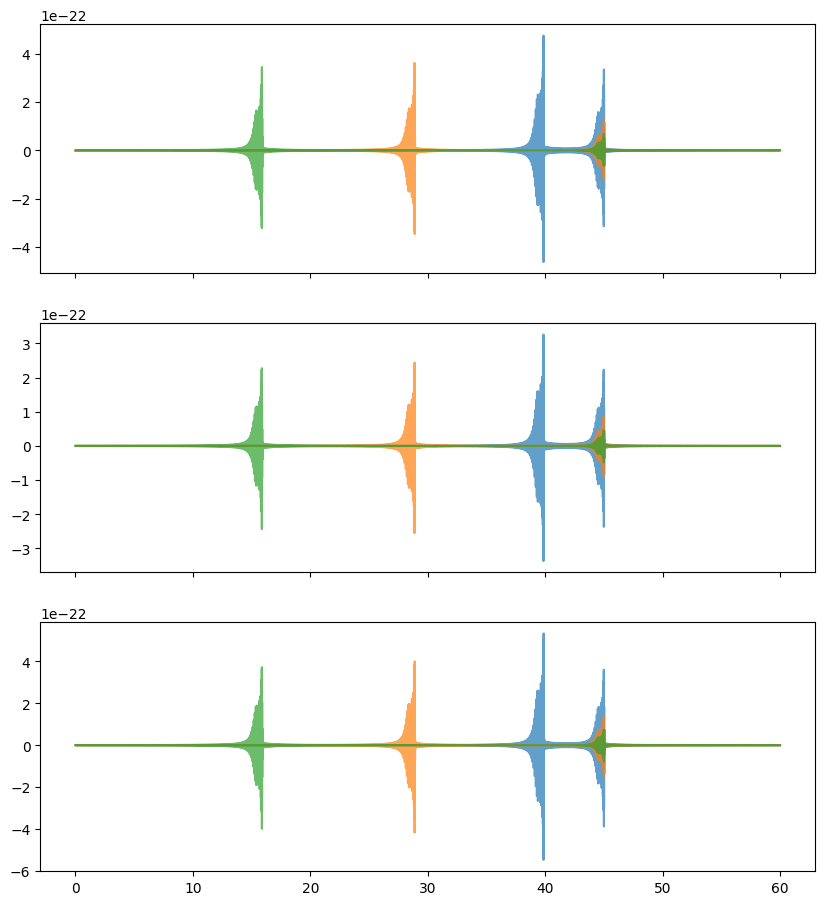

In [14]:
cplx_zeros = np.zeros((freq_array.size, shape), dtype=np.complex128)
post_merger_time = -15
n_index = int(post_merger_time * sampling_frequency)

fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)

for ifo_strain, ax in zip((H1_strain, L1_strain, V1_strain), axes):
    # Make use of jax numpy `.at.set` copying feature
    full_strain = cplx_zeros.at[freq_mask].set(ifo_strain)

    full_TD_strain = np.fft.irfft(full_strain, axis=0) * sampling_frequency

    for idx, h1 in enumerate(full_TD_strain.T):
        ax.plot(time_array, np.roll(h1, n_index), c=f'C{idx}', label='flexible', alpha=0.7)

In [15]:
model_parameters['relative_distance']

Array([0.67715735, 0.34621048, 0.19143164], dtype=float64)

In [16]:
HLV_fisher = HLV_Lensed.FisherMatr(model_parameters, res=1000)

Computing Fisher for H1...
Computing Fisher for L1...
Computing Fisher for V1...
Done.


In [17]:
import numpy as onp
keys = list(model_parameters.keys()).copy()
reduce_fisher_mat, _ = reduce_Fisher_matrix(HLV_fisher, keys=keys)
# Convert to regular numpy for float128 support
reduce_fisher_mat = onp.array(reduce_fisher_mat)

print("\nThe Fisher matrices:")
fisher_mats_iter = onp.moveaxis(reduce_fisher_mat, 2, 0)
for matrix in fisher_mats_iter:
    row = f'{"":8}   ' + '  '.join([f'{col_key:^11}' for col_key in keys])
    print(row)
    for rdx, row_key in enumerate(keys):
        row = f'{row_key:>8}  '
        for cdx, col_key in enumerate(keys):
            row += f'{matrix[rdx][cdx]:+11.3e}  '
        print(row)
    print('--------------------')
print('=================================================================')

reduced_cov_mats, ie = CovMatr(reduce_fisher_mat)
covar_mats_iter = onp.moveaxis(reduced_cov_mats, 2, 0)

print("\nThe Covariance matrices:")
for matrix in covar_mats_iter:
    row = f'{"":8}   ' + '  '.join([f'{col_key:^11}' for col_key in keys])
    print(row)
    for rdx, row_key in enumerate(keys):
        row = f'{row_key:>8}  '
        for cdx, col_key in enumerate(keys):
            row += f'{matrix[rdx][cdx]:+11.3e}  '
        print(row)


The Fisher matrices:
               phi          dL           psi         theta        tcoal        chi2z        iota          eta         phase        chi1z         Mc       delta_iota   delta_phase  relative_distance  relative_mass  delta_time 
     phi   +3.204e+03   -9.611e+02   -2.489e+03   +2.260e+03   +6.123e+05   +8.488e+02   +1.225e+03   +1.794e+05   -1.412e+03   +3.328e+04   -8.966e+02   +6.887e+02   -5.982e+02   -2.059e+03   -3.225e+04   +2.420e+10  
      dL   -9.611e+02   +8.006e+02   +1.012e+03   +1.553e+03   +6.989e-02   -1.884e+02   -9.748e-01   -5.540e+03   +8.306e-15   -4.532e+02   -1.380e+01   -6.564e+01   -3.823e+01   +1.664e+03   -2.745e+03   +1.327e+09  
     psi   -2.489e+03   +1.012e+03   +2.587e+03   +3.401e+03   +2.583e+03   -1.792e+02   +1.803e+00   -6.091e+03   -3.174e+00   -4.098e+02   -2.636e+01   +1.342e+02   -3.589e+02   +2.114e+03   -1.970e+04   +1.194e+10  
   theta   +2.260e+03   +1.553e+03   +3.401e+03   +7.680e+04   +3.640e+06   +4.306e+03   +9.918

In [18]:
keys = list(model_parameters.keys()).copy()
reduce_fisher_mat, _ = reduce_Fisher_matrix(HLV_fisher, keys=keys)
# Convert to regular numpy for float128 support
reduce_fisher_mat = onp.array(reduce_fisher_mat)
reduced_cov_mats, ie = CovMatr(reduce_fisher_mat)

dt_idx = keys.index('delta_time')
# Convert delta_time from days to seconds
reduced_cov_mats[dt_idx, :, :] *= DAY_TO_SEC
reduced_cov_mats[:, dt_idx, :] *= DAY_TO_SEC


labels = {
    'Mc': r'${\cal M}\,/\,M_\odot$',
    'eta': r'$\eta$',
    'dL': r'$D_{\rm L}\,/\,{\rm Gpc}$',
    'theta': r'$\alpha\,/\,{\rm rad}$',
    'phi': r'$\delta\,/\,{\rm rad}$',
    'iota': r'$\iota\,/\,{\rm rad}$',
    'psi': r'$\psi\,/\,{\rm rad}$',
    'tcoal': r'$t_{\rm c}\,/\,{\rm s}$',
    'phase': r'$\phi\,/\,{\rm rad}$',
    'chi1z': r'$\chi_{1z}$',
    'chi2z': r'$\chi_{2z}$',
    'R_orbit': r'$R_{\rm orb}\,/\,R_{\rm S}$',
    'M_lz': r'$M_{\rm Lz}\,/\,M_\odot$',
    'src_pos': r'$y$',
    'delta_iota': r'$\Delta \iota\,/\,{\rm rad}$',
    'delta_phase': r'$\Delta \phi\,/\,{\rm rad}$',
    'delta_time': r'$\Delta t\,/\,{\rm s}$',
    'relative_mass': r'${\cal M}_2 \,/\,{\cal M}_1$',
    'relative_distance': r'$D_{L,2} \,/\,D_{L,1}$',
}

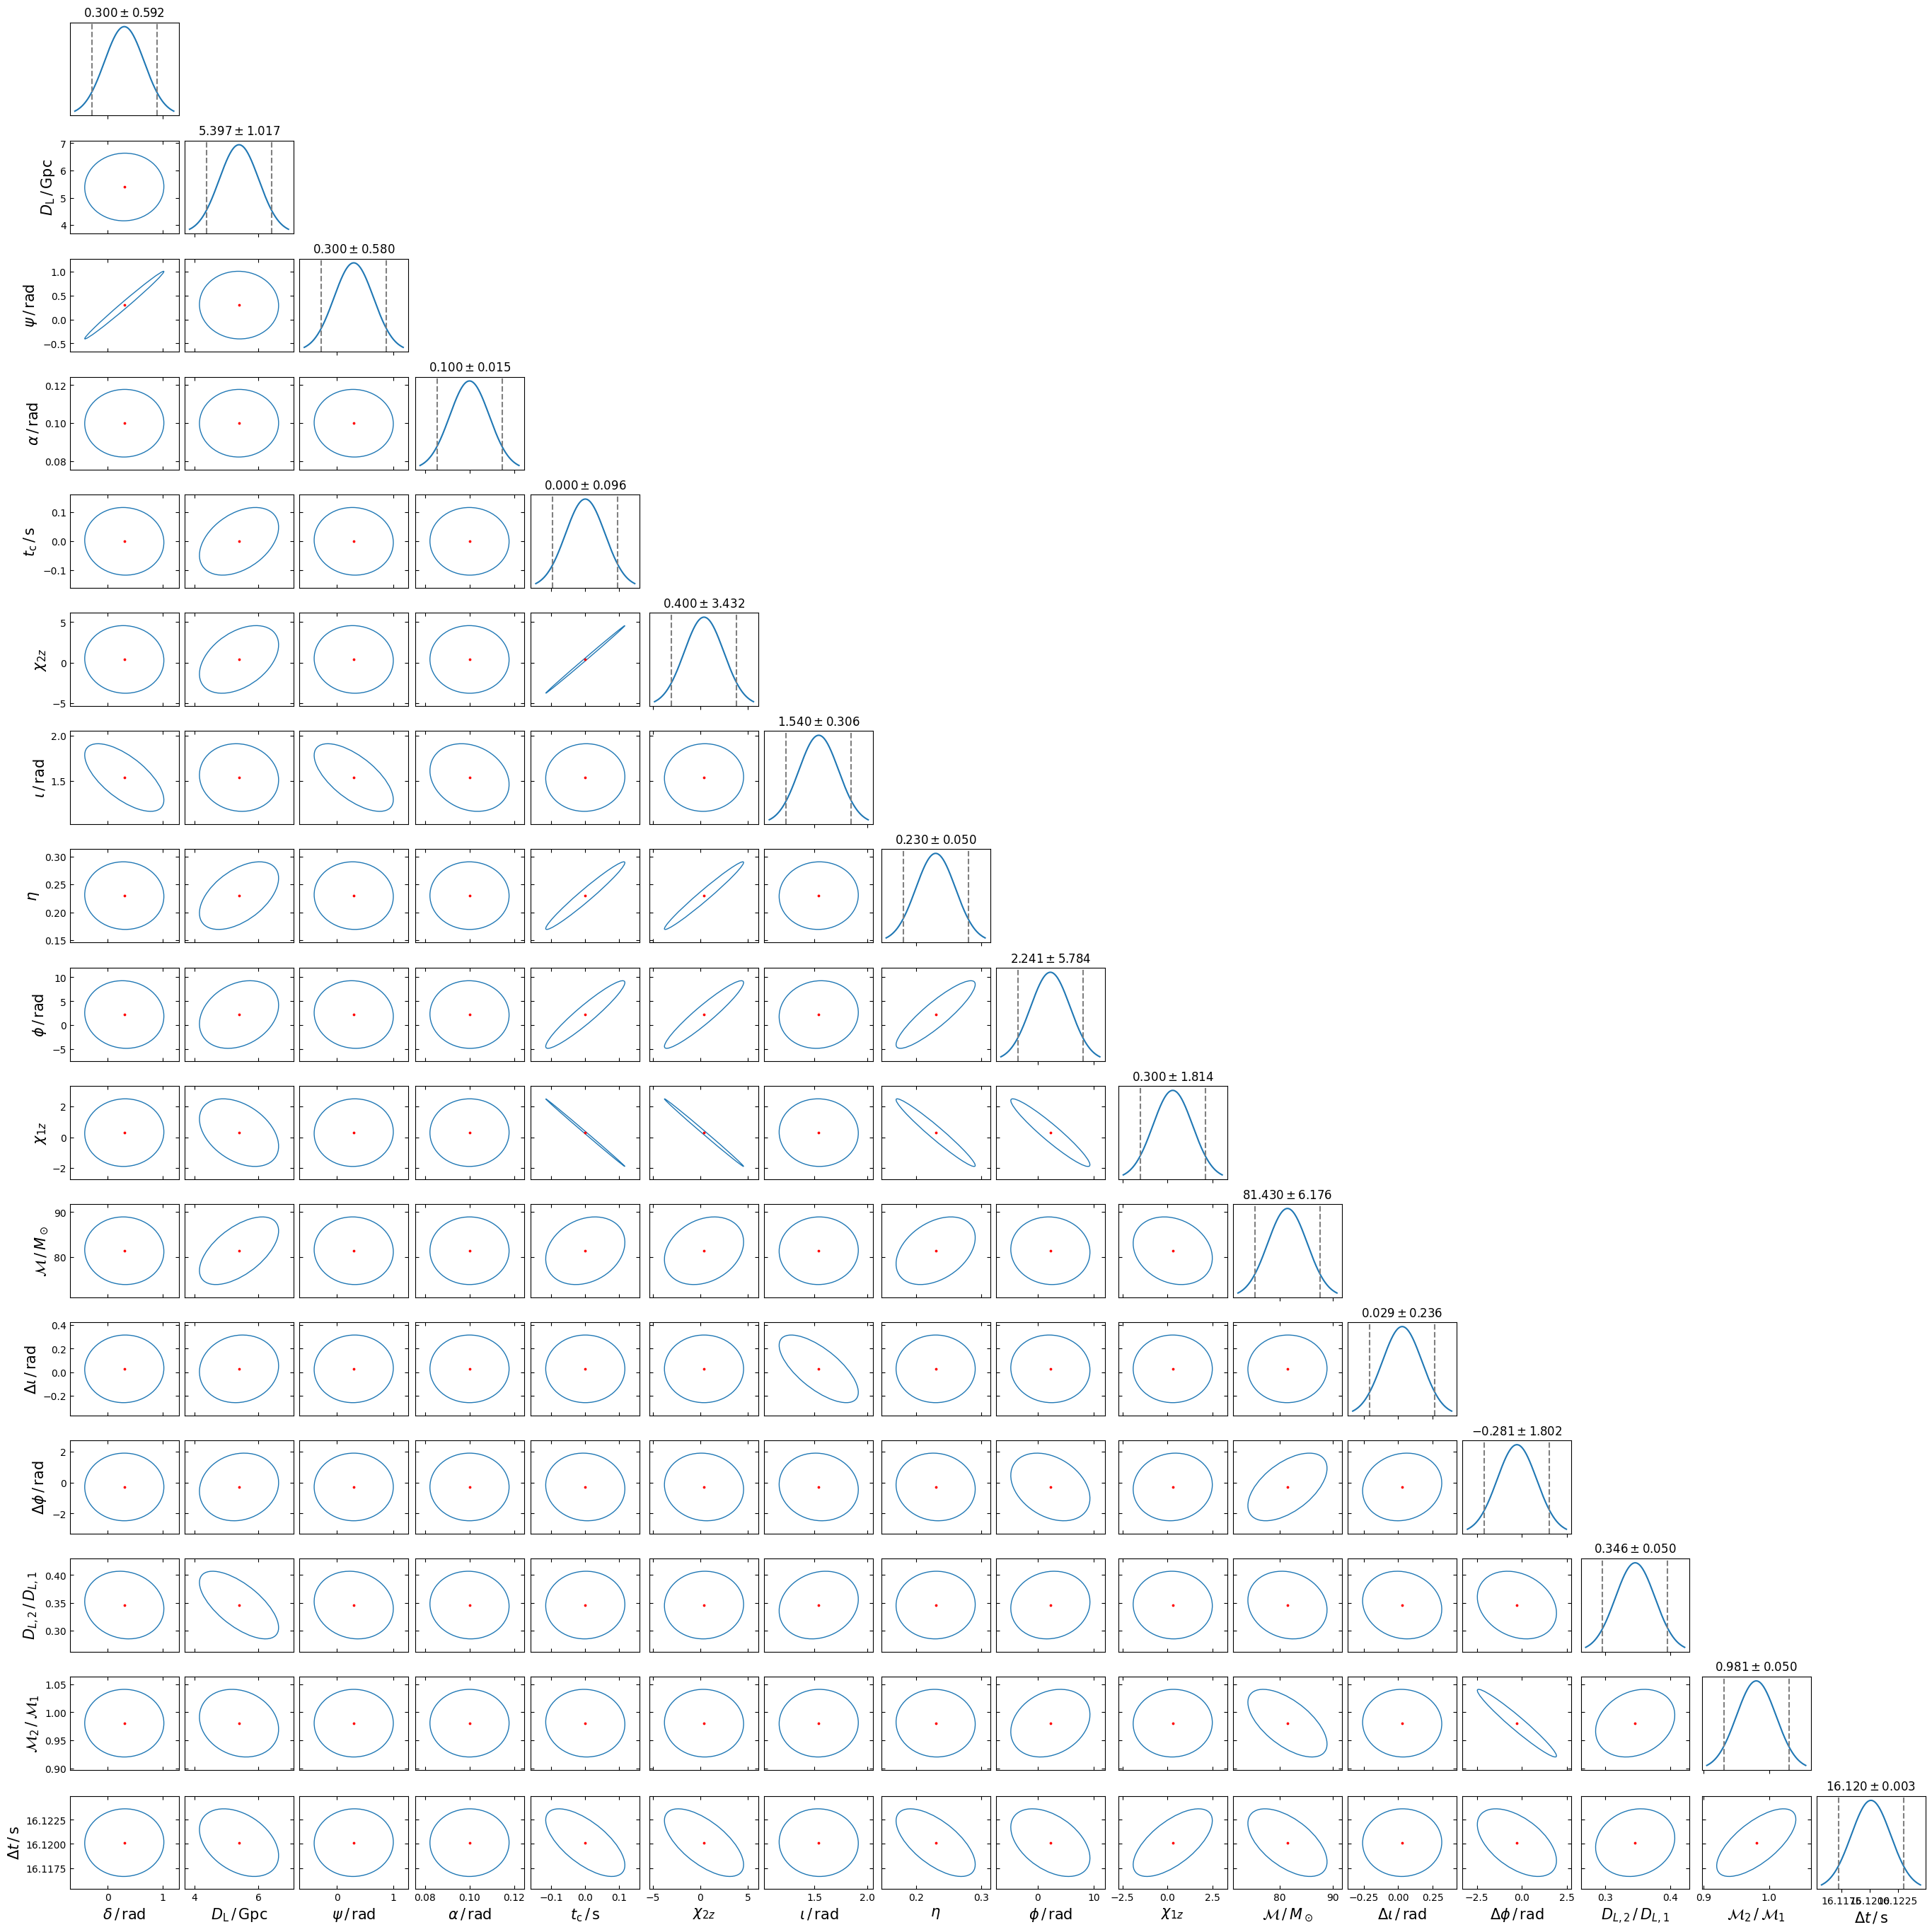

In [19]:
idx = 1
indices = np.arange(0, len(keys))
parameters = {key: val[idx] for key, val in model_parameters.items()}
parameters['delta_time'] *= DAY_TO_SEC 

fig = plot_corners(
    reduced_cov_mats[:, :, idx], keys, indices, 
    event=parameters, labels=labels, color='C0'
)

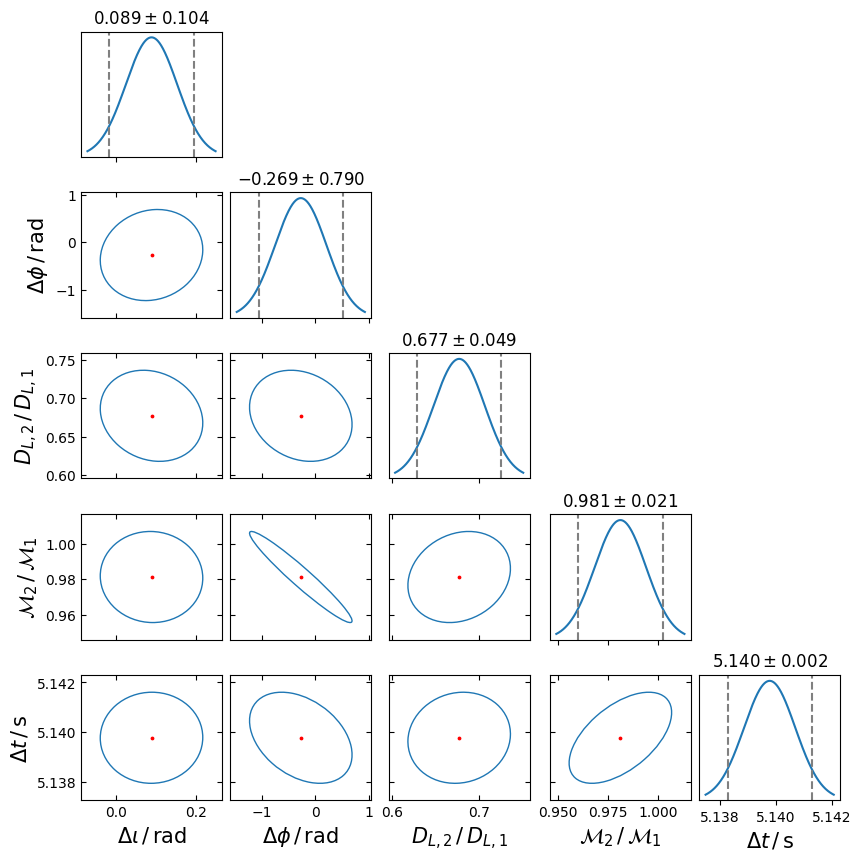

In [20]:
idx = 0
indices = np.arange(11, len(keys))
parameters = {key: val[idx] for key, val in model_parameters.items()}
parameters['delta_time'] *= DAY_TO_SEC

fig = plot_corners(
    reduced_cov_mats[:, :, idx], keys[11:], indices, 
    event=parameters, labels=labels, color='C0'
)
fig.savefig('flexible_model_Cov_sub_corner.png', dpi=300)